In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = sns.load_dataset('titanic')

# Check if it loaded correctly
print("Pandas version:", pd.__version__)
print("Dataset shape:", df.shape)

Pandas version: 3.0.1
Dataset shape: (891, 15)


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = sns.load_dataset('titanic')

# Check if it loaded correctly
print("Pandas version:", pd.__version__)
print("Dataset shape:", df.shape)

Pandas version: 3.0.1
Dataset shape: (891, 15)


In [6]:
# Create a sub-section of the data
df_sub = df[['survived', 'pclass', 'sex', 'age', 'fare']]

# Display the first 5 rows of your new, cleaner table
df_sub.head()

,survived,pclass,sex,age,fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


In [7]:
# a) Get an overview of all numeric columns
print(df.describe())

# b) What is the mean (average) age?
mean_age = df['age'].mean()
print(f"\nThe average age of a passenger was: {mean_age:.1f} years")

# c) What is the median fare?
median_fare = df['fare'].median()
print(f"The median ticket price was: {median_fare:.2f} GBP")

         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200

The average age of a passenger was: 29.7 years
The median ticket price was: 14.45 GBP


In [8]:
# Exercise 7: Survival rate by sex
survival_by_sex = df.groupby('sex')['survived'].mean()
print("Survival Rate by Sex:")
print(survival_by_sex)

# Exercise 8: Average fare by class
avg_fare_by_class = df.groupby('pclass')['fare'].mean()
print("\nAverage Fare by Class:")
print(avg_fare_by_class)

Survival Rate by Sex:
sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

Average Fare by Class:
pclass
1    84.154687
2    20.662183
3    13.675550
Name: fare, dtype: float64


In [9]:
# a) Who was the oldest passenger?
oldest = df.sort_values('age', ascending=False).head(1)
print("Oldest Passenger Details:")
print(oldest[['age', 'sex', 'pclass', 'survived']])

# b) What was the most expensive ticket?
priciest = df.sort_values('fare', ascending=False).head(1)
print("\nMost Expensive Ticket Details:")
print(priciest[['fare', 'pclass', 'survived']])

Oldest Passenger Details:
      age   sex  pclass  survived
630  80.0  male       1         1

Most Expensive Ticket Details:
         fare  pclass  survived
258  512.3292       1         1


In [10]:
# Create a new column 'is_child'
df['is_child'] = df['age'] < 16

# Compare survival rates
child_survival = df.groupby('is_child')['survived'].mean().round(2)
print("Survival Rate (True = Child, False = Adult):")
print(child_survival)


Survival Rate (True = Child, False = Adult):
is_child
False    0.36
True     0.59
Name: survived, dtype: float64


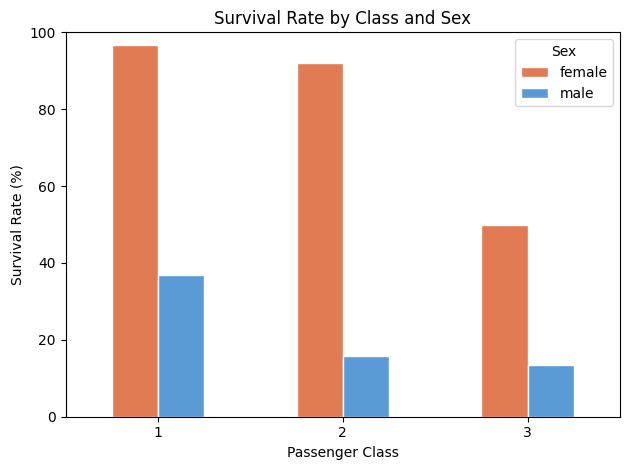

In [11]:
# Create a pivot table for the chart
pivot = df.groupby(['pclass', 'sex'])['survived'].mean().unstack() * 100

# Plotting
pivot.plot(kind='bar', color=['#e07b54', '#5b9bd5'], edgecolor='white')

# Formatting the chart
plt.title('Survival Rate by Class and Sex')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

In [12]:
# Create family_size column: siblings + parents + yourself
df['family_size'] = df['sibsp'] + df['parch'] + 1

# Calculate and sort survival rate by family size
family_results = (df.groupby('family_size')['survived']
                    .mean().round(2)
                    .sort_values(ascending=False))

print("Survival Rate by Family Size:")
print(family_results)

Survival Rate by Family Size:
family_size
4     0.72
3     0.58
2     0.55
7     0.33
1     0.30
5     0.20
6     0.14
8     0.00
11    0.00
Name: survived, dtype: float64
